# SA — Clasificación con k-NN

**Materia:** Extracción de Conocimiento de Base de Datos
**Docente:** Filiberto Ruíz Hernández
**Alumno:** Mario Alberto Ramírez Martínez — Matrícula 2023371044
**Universidad:** Universidad Tecnológica de Querétaro — Ingeniería en Gestión de Desarrollo de Software
**Semestre:** 2026 — Fecha: 2026-08-07

---

## 2. Clasificación sobre breast-cancer.csv

Clasificar tumores como benignos (B) o malignos (M) usando el algoritmo de los k vecinos más cercanos (k-NN) sobre el conjunto breast-cancer.csv, con optimización de hiperparámetros y evaluación completa del modelo.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE = "/home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2"
DATA = os.path.join(BASE, "data/raw")
IMG = os.path.join(BASE, "reporte/img")
MODELOS = os.path.join(BASE, "modelos")
os.makedirs(IMG, exist_ok=True)
os.makedirs(MODELOS, exist_ok=True)
print("Rutas listas: DATA =", DATA)

Rutas listas: DATA = /home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2/data/raw


## Justificación del algoritmo

Se elige **k-NN** porque el conjunto tiene 30 características numéricas continuas y una etiqueta binaria, y k-NN es un algoritmo de clasificación no paramétrico sencillo y fácil de interpretar: clasifica cada muestra según la mayoría de sus k vecinos más cercanos en el espacio de características. Además permite una búsqueda de hiperparámetros clara (k, tipo de pesos y métrica de distancia) y no asume linealidad, a diferencia de la regresión logística.

In [2]:
df = pd.read_csv(os.path.join(DATA, "breast-cancer.csv"))
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Dimensiones:", df.shape)
print("\nNulos:", df.isna().sum().sum())
print("\nDistribución de diagnóstico:\n", df["diagnosis"].value_counts())

Dimensiones: (569, 32)

Nulos: 0

Distribución de diagnóstico:
 diagnosis
B    357
M    212
Name: count, dtype: int64


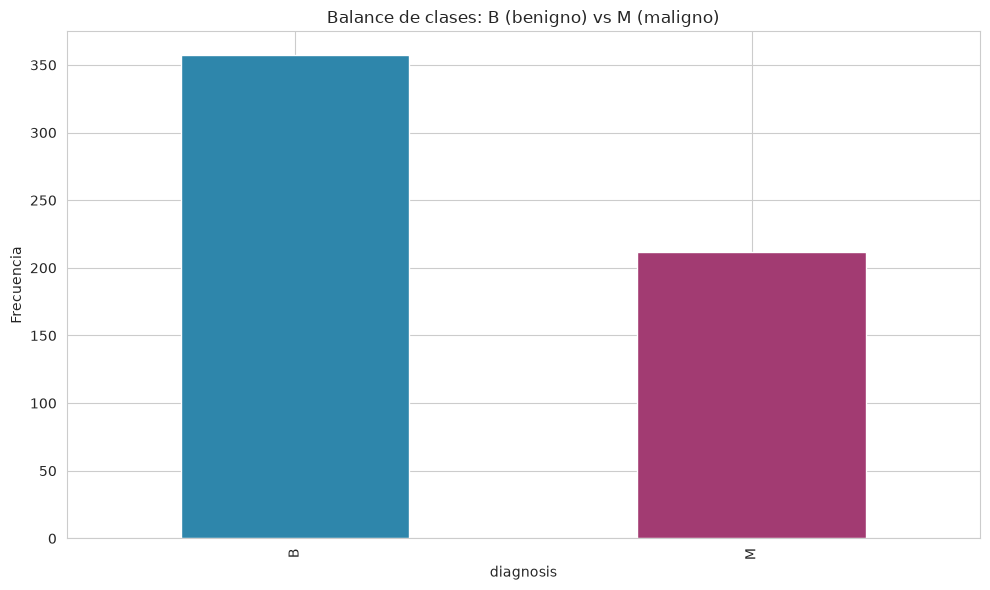

In [4]:
df["diagnosis"].value_counts().plot(kind="bar", color=["#2E86AB", "#A23B72"])
plt.title("Balance de clases: B (benigno) vs M (maligno)")
plt.xlabel("diagnosis"); plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "balance_breast.png"), dpi=150, bbox_inches="tight")
plt.show()

## Diseño del modelo (paso a paso)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"M": 1, "B": 0})
print("Características:", X.shape[1], "| Muestras:", X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Entrenamiento:", X_train.shape[0], "| Prueba:", X_test.shape[0])

Características: 30 | Muestras: 569
Entrenamiento: 426 | Prueba: 143


In [6]:
# k-NN es sensible a la escala: estandarizamos sobre el conjunto de entrenamiento
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Media (aprox. 0) y desviación (aprox. 1) tras escalado:", X_train_s.mean().round(3), X_train_s.std().round(3))

Media (aprox. 0) y desviación (aprox. 1) tras escalado: -0.0 1.0


## Evaluación y optimización — búsqueda de hiperparámetros

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
grid = {"knn__n_neighbors": list(range(1, 16)),
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"]}
gs = GridSearchCV(pipe, grid, cv=5, scoring="accuracy", n_jobs=-1)
gs.fit(X_train, y_train)
print("Mejores hiperparámetros:", gs.best_params_)
print("Mejor accuracy (CV):", round(gs.best_score_, 4))

Mejores hiperparámetros: {'knn__metric': 'euclidean', 'knn__n_neighbors': 6, 'knn__weights': 'distance'}
Mejor accuracy (CV): 0.9695


### Evaluación del modelo óptimo en prueba

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

modelo = gs.best_estimator_
y_pred = modelo.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))
print("\n", classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

Accuracy : 0.958
Precision: 0.9796
Recall   : 0.9057
F1       : 0.9412

               precision    recall  f1-score   support

     Benigno       0.95      0.99      0.97        90
     Maligno       0.98      0.91      0.94        53

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



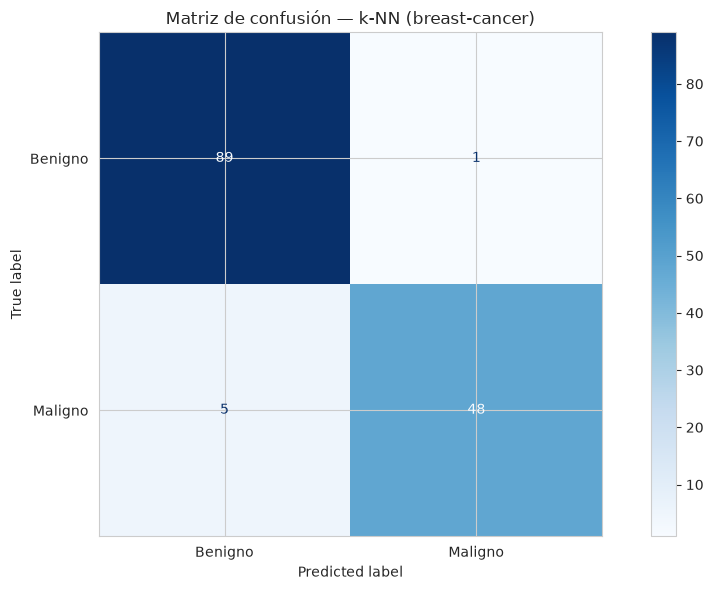

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Benigno", "Maligno"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión — k-NN (breast-cancer)")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "confusion_knn.png"), dpi=150, bbox_inches="tight")
plt.show()

### Curva de accuracy según k (análisis de sensibilidad)

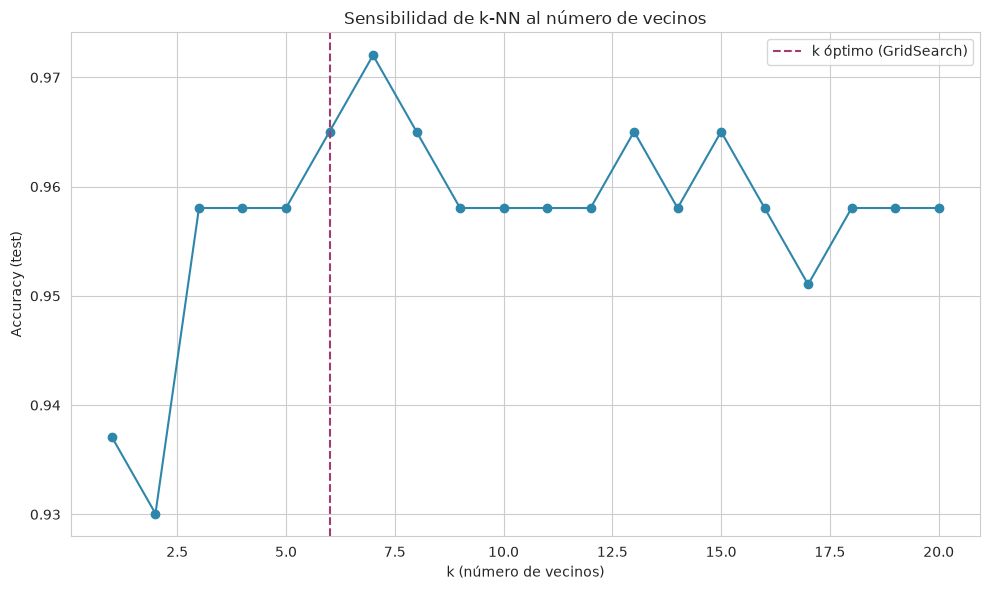

In [10]:
ks = list(range(1, 21))
accs = []
for k in ks:
    m = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
    m.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure()
plt.plot(ks, accs, marker="o", color="#2E86AB")
plt.axvline(gs.best_params_["knn__n_neighbors"], color="#A23B72", ls="--", label="k óptimo (GridSearch)")
plt.xlabel("k (número de vecinos)"); plt.ylabel("Accuracy (test)")
plt.title("Sensibilidad de k-NN al número de vecinos")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(IMG, "curva_k_knn.png"), dpi=150, bbox_inches="tight")
plt.show()

### Visualización con PCA (proyección 2D de las clases)

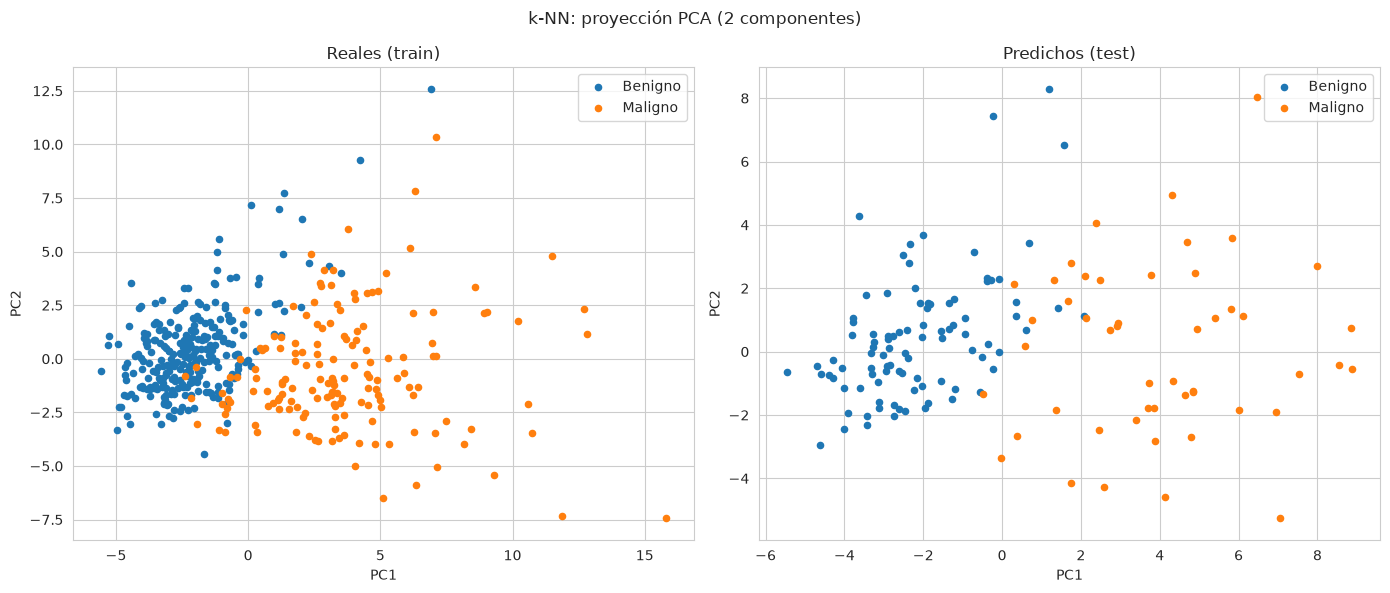

Varianza explicada por PC1-PC2: [0.438 0.192]


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_train_s)
X2t = pca.transform(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (Xp, yy, titulo) in zip(axes, [(X2, y_train, "Reales (train)"), (X2t, y_pred, "Predichos (test)")]):
    for cl in [0, 1]:
        ax.scatter(Xp[np.asarray(yy) == cl, 0], Xp[np.asarray(yy) == cl, 1], s=20, label="Maligno" if cl else "Benigno")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(titulo); ax.legend()
plt.suptitle("k-NN: proyección PCA (2 componentes)")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "pca_knn_classes.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Varianza explicada por PC1-PC2:", pca.explained_variance_ratio_.round(3))

## Guardar el modelo

In [12]:
import joblib
joblib.dump(modelo, os.path.join(MODELOS, "breast_knn.pkl"))
print("Modelo (pipeline escalador + k-NN) guardado en modelos/breast_knn.pkl")

Modelo (pipeline escalador + k-NN) guardado en modelos/breast_knn.pkl


## Verificación de integridad (recarga del modelo)

In [13]:
modelo_cargado = joblib.load(os.path.join(MODELOS, "breast_knn.pkl"))
y_verif = modelo_cargado.predict(X_test)
print("Accuracy tras recargar:", round(accuracy_score(y_test, y_verif), 4))
print("Coincide:", np.array_equal(y_verif, y_pred))

Accuracy tras recargar: 0.958
Coincide: True
